In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import networkx as nx

In [2]:
df_init = pd.read_csv("final_table.csv")
df_init.head()

,cluster,target,contig,SQ_gene_content_set,SQ_pathway,SQ_score,taxonomy,bitscore_list,evalue_list
0,63,"GCA_902754915.1_GLIGFB_00196,GCA_902754915.1_G...",CACVLH010000001.1,"sqiA,sqiK",sulfo-EMP,min,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[182.0, 185.0]","[7.299999999999999e-52, 4.5899999999999996e-55]"
1,66,"GCA_902754915.1_GLIGFB_00381,GCA_902754915.1_G...",CACVLH010000002.1,"sqvB,sqvD,sqwF,sqwG,sqwH,sqwI",sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[142.0, 217.0, 162.0, 291.0, 298.0, 255.0]","[1.6599999999999999e-40, 5.99e-66, 3.31e-50, 1..."
2,271,"GCA_902755405.1_GNFANA_00528,GCA_902755405.1_G...",CACVMX010000032.1,"sqvA,sqwG,sqwH",sulfo-TAL,min,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[232.0, 227.0, 148.0]","[2.86e-74, 1.79e-71, 3.93e-43]"
3,387,"GCA_902755455.1_HAJFOH_00002,GCA_902755455.1_H...",CACVNO010000001.1,"sqiA,sqiK",sulfo-EMP,min,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[160.0, 182.0]","[1.03e-45, 7.299999999999999e-52]"
4,392,"GCA_902755455.1_HAJFOH_00507,GCA_902755455.1_H...",CACVNO010000004.1,"sqvD,sqwF,sqwG,sqwH,sqwI,yihQ",sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[391.0, 275.0, 295.0, 292.0, 159.0, 206.0]","[1.12e-125, 1.51e-86, 3.47e-99, 8.999999999999..."


In [3]:
def explode_row(row):
    targets = row["target"].split(",")

    new_rows = []
    for t in targets:
        new_rows.append({
            "cluster": row["cluster"],
            "contig": row["contig"],
            "target": t,
            "pathway": row["SQ_pathway"],
            "score": row["SQ_score"],
            "taxonomy": row["taxonomy"]
        })
    
    return pd.DataFrame(new_rows)

df_expanded = pd.concat(
    [explode_row(row) for _, row in df_init.iterrows()],
    ignore_index=True
)

In [4]:
df_expanded.head()

,cluster,contig,target,pathway,score,taxonomy
0,63,CACVLH010000001.1,GCA_902754915.1_GLIGFB_00196,sulfo-EMP,min,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...
1,63,CACVLH010000001.1,GCA_902754915.1_GLIGFB_00197,sulfo-EMP,min,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...
2,66,CACVLH010000002.1,GCA_902754915.1_GLIGFB_00381,sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...
3,66,CACVLH010000002.1,GCA_902754915.1_GLIGFB_00384,sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...
4,66,CACVLH010000002.1,GCA_902754915.1_GLIGFB_00385,sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...


In [5]:
meta = pd.read_csv("meta_table_merge.tsv", sep="\t")

In [6]:
meta.head()

,MAG,query,target,identity,aln_len,evalue,bitscore,product,contig,start,end,taxonomy,Protein ID,Organism name,Locus,Gene,Function,PFAM ID,Reference
0,GCA_902803065.1,AAK90112.1,GCA_902803065.1_CCEEBC_01630,28.9,201,3.600000e-09,55.5,Oxidoreductase,CADCOP010000322.1,7080,8081,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,AAK90112.1,Agrobacterium fabrum str. C58,sulfo- ASMO,squF,glucose-6-dehydrogenase,PF00248,https://doi.org/10.1073/pnas.2116022119
1,GCA_902803065.1,AAK90112.1,GCA_902803065.1_CCEEBC_01592,27.9,201,4.830000e-09,55.1,Oxidoreductase,CADCOP010000315.1,2222,3223,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,AAK90112.1,Agrobacterium fabrum str. C58,sulfo- ASMO,squF,glucose-6-dehydrogenase,PF00248,https://doi.org/10.1073/pnas.2116022119
2,GCA_902803055.1,AAK90112.1,GCA_902803055.1_MMPJKM_00615,27.5,182,4.970000e-06,45.8,Aryl-alcohol dehydrogenase (NADP(+)),CADCOR010000114.1,596,1555,d__Bacteria;p__Bacillota;c__Bacilli;o__Erysipe...,AAK90112.1,Agrobacterium fabrum str. C58,sulfo- ASMO,squF,glucose-6-dehydrogenase,PF00248,https://doi.org/10.1073/pnas.2116022119
3,GCA_902803065.1,WP_017967307.1,GCA_902803065.1_CCEEBC_00013,35.1,544,2.750000e-100,313.0,Dihydroxy-acid dehydratase,CADCOP010000003.1,2137,3807,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,WP_017967307.1,Rhizobium leguminosarum bv. trifoliiSRDI565,sulfo-ED,sedC,SG dehydratase,PF00920,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...
4,GCA_902803035.1,WP_017967307.1,GCA_902803035.1_BOCBGN_01878,35.0,534,4.870000e-92,292.0,Dihydroxy-acid dehydratase,CADCON010000232.1,7183,8844,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,WP_017967307.1,Rhizobium leguminosarum bv. trifoliiSRDI565,sulfo-ED,sedC,SG dehydratase,PF00920,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...


In [7]:
df = df_expanded.merge(
    meta[["target", "Gene", "MAG"]],
    on="target",
    how="left"
)

In [8]:
df.head()

,cluster,contig,target,pathway,score,taxonomy,Gene,MAG
0,63,CACVLH010000001.1,GCA_902754915.1_GLIGFB_00196,sulfo-EMP,min,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,sqiK,GCA_902754915.1
1,63,CACVLH010000001.1,GCA_902754915.1_GLIGFB_00197,sulfo-EMP,min,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,sqiA,GCA_902754915.1
2,66,CACVLH010000002.1,GCA_902754915.1_GLIGFB_00381,sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,sqvB,GCA_902754915.1
3,66,CACVLH010000002.1,GCA_902754915.1_GLIGFB_00384,sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,sqwF,GCA_902754915.1
4,66,CACVLH010000002.1,GCA_902754915.1_GLIGFB_00385,sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,sqwI,GCA_902754915.1


In [9]:
def extract_phylum(tax):
    for x in tax.split(";"):
        if x.startswith("p__"):
            return x.replace("p__", "")
    return "Unknown"

df["Phylum"] = df["taxonomy"].apply(extract_phylum)

In [10]:
def extract_rank(tax, rank):
    if pd.isna(tax):
        return "Unknown"
    
    for x in tax.split(";"):
        if x.startswith(rank + "__"):
            return x.split("__")[1]
    
    return "Unknown"

In [11]:
df["Phylum"] = df["taxonomy"].apply(lambda x: extract_rank(x, "p"))

In [12]:
ranks = {
    "d": "Domain",
    "p": "Phylum",
    "c": "Class",
    "o": "Order",
    "f": "Family",
    "g": "Genus",
    "s": "Species"
}

for k, v in ranks.items():
    df[v] = df["taxonomy"].apply(lambda x: extract_rank(x, k))

🔬 1. pathway vs taxonomy
df_filtered_genes.groupby(["Phylum", "SQ_pathway"]).size()
🔬 2. enrichment по родам
df_filtered_genes.groupby("Genus")["gene"].count()
🔬 3. сравнение sulfo-EMP vs sulfo-TK
df_filtered_genes.groupby(["Phylum", "SQ_pathway"])["cluster"].nunique()
🔬 4. completeness per MAG
df_filtered_genes.groupby(["Genus", "cluster"])["gene"].nunique()

In [13]:
df.head()


,cluster,contig,target,pathway,score,taxonomy,Gene,MAG,Phylum,Domain,Class,Order,Family,Genus,Species
0,63,CACVLH010000001.1,GCA_902754915.1_GLIGFB_00196,sulfo-EMP,min,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,sqiK,GCA_902754915.1,Bacillota,Bacteria,Clostridia,Oscillospirales,Oscillospiraceae,CAG-103,CAG-103 sp900317905
1,63,CACVLH010000001.1,GCA_902754915.1_GLIGFB_00197,sulfo-EMP,min,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,sqiA,GCA_902754915.1,Bacillota,Bacteria,Clostridia,Oscillospirales,Oscillospiraceae,CAG-103,CAG-103 sp900317905
2,66,CACVLH010000002.1,GCA_902754915.1_GLIGFB_00381,sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,sqvB,GCA_902754915.1,Bacillota,Bacteria,Clostridia,Oscillospirales,Oscillospiraceae,CAG-103,CAG-103 sp900317905
3,66,CACVLH010000002.1,GCA_902754915.1_GLIGFB_00384,sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,sqwF,GCA_902754915.1,Bacillota,Bacteria,Clostridia,Oscillospirales,Oscillospiraceae,CAG-103,CAG-103 sp900317905
4,66,CACVLH010000002.1,GCA_902754915.1_GLIGFB_00385,sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,sqwI,GCA_902754915.1,Bacillota,Bacteria,Clostridia,Oscillospirales,Oscillospiraceae,CAG-103,CAG-103 sp900317905


In [14]:
tax_cols = ["Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

df_unique = df.drop_duplicates(subset=["MAG", "Gene"])[["MAG", "Gene"] + tax_cols]

df_unique.head()

,MAG,Gene,Domain,Phylum,Class,Order,Family,Genus,Species
0,GCA_902754915.1,sqiK,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,CAG-103,CAG-103 sp900317905
1,GCA_902754915.1,sqiA,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,CAG-103,CAG-103 sp900317905
2,GCA_902754915.1,sqvB,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,CAG-103,CAG-103 sp900317905
3,GCA_902754915.1,sqwF,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,CAG-103,CAG-103 sp900317905
4,GCA_902754915.1,sqwI,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,CAG-103,CAG-103 sp900317905


In [15]:
presence_matrix = (
    df_unique.assign(val=1)
    .pivot_table(
        index="MAG",      # строки = MAGs
        columns="Gene",   # колонки = genes
        values="val",
        aggfunc="max",
        fill_value=0
    )
)

In [16]:
print(presence_matrix.shape)
presence_matrix.head()

(323, 23)


Gene,sedA,sedB,sedC,sedD,slaB,sqgA,sqiA,sqiK,squD,squF,...,sqwD,sqwF,sqwG,sqwH,sqwI,ssuE,yihQ,yihS,yihU,yihV
MAG,,,,,,,,,,,,,,,,,,,,,
GCA_902754915.1,0,0,0,0,0,0,1,1,0,0,...,0,1,1,1,1,0,0,0,0,0
GCA_902755405.1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
GCA_902755455.1,0,0,0,0,0,0,1,1,0,0,...,0,1,1,1,1,0,1,0,0,0
GCA_902755505.1,1,0,0,0,1,0,1,0,0,1,...,0,0,0,0,0,0,0,1,0,1
GCA_902755545.1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [17]:
gene_freq = presence_matrix.sum(axis=0)

print("Редкие гены:")
print(gene_freq.sort_values().head())

print("\nЧастые гены:")
print(gene_freq.sort_values().tail())

Редкие гены:
Gene
sedB    1
sedC    1
sqwD    1
yihS    1
ssuE    2
dtype: int64

Частые гены:
Gene
sqwH    115
sqwG    123
sqvD    130
sqiA    162
sqvA    163
dtype: int64


In [18]:
#presence_matrix = presence_matrix.loc[:, gene_freq >= 2]

In [19]:
X = presence_matrix.astype(int)

cooc = X.T @ X

In [20]:
cooc.iloc[:5, :5]

Gene,sedA,sedB,sedC,sedD,slaB
Gene,,,,,
sedA,13,0,1,1,3
sedB,0,1,0,1,0
sedC,1,0,1,1,1
sedD,1,1,1,3,1
slaB,3,0,1,1,4


In [21]:
# frequencies (ВАЖНО: .values)
freq = X.sum(axis=0).values

# intersection
cooc = X.T @ X

# union
union = np.add.outer(freq, freq) - cooc.values
union = union.astype(float)
union[union == 0] = np.nan

# jaccard
jaccard = pd.DataFrame(
    cooc.values / union,
    index=X.columns,
    columns=X.columns
).fillna(0)

np.fill_diagonal(jaccard.values, 0)

In [22]:
jaccard.describe()

Gene,sedA,sedB,sedC,sedD,slaB,sqgA,sqiA,sqiK,squD,squF,...,sqwD,sqwF,sqwG,sqwH,sqwI,ssuE,yihQ,yihS,yihU,yihV
count,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,...,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000
mean,0.043716,0.018538,0.033431,0.048323,0.059931,0.018852,0.101945,0.083248,0.031884,0.045911,...,0.004612,0.132080,0.133845,0.135396,0.134767,0.032091,0.115481,0.018259,0.060241,0.056422
std,0.049527,0.070034,0.084950,0.099675,0.093924,0.043801,0.135342,0.127566,0.139073,0.060199,...,0.006454,0.208548,0.208180,0.211276,0.211111,0.139130,0.152298,0.054542,0.127186,0.090363
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.010187,0.000000,0.000000,0.000000,0.000000,0.000000,0.006173,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.012500
50%,0.028777,0.000000,0.000000,0.000000,0.000000,0.000000,0.035503,0.010753,0.000000,0.012821,...,0.000000,0.017857,0.008130,0.008696,0.014286,0.000000,0.014706,0.000000,0.000000,0.024590
75%,0.069048,0.000000,0.010096,0.028009,0.101852,0.015385,0.157297,0.142797,0.000000,0.066667,...,0.008413,0.248165,0.186574,0.195740,0.242647,0.000000,0.205934,0.003086,0.024490,0.048829
max,0.214286,0.333333,0.333333,0.333333,0.250000,0.200000,0.517857,0.517857,0.666667,0.187500,...,0.018182,0.800000,0.830769,0.830769,0.800000,0.666667,0.467532,0.250000,0.467532,0.406977


In [23]:
print(jaccard.min().min(), jaccard.max().max())

0.0 0.8307692307692308


In [24]:
import numpy as np
import pandas as pd

# -------------------------
# 1. БЕРЁМ ПРАВИЛЬНУЮ МАТРИЦУ
# -------------------------
X = presence_matrix.copy()

# -------------------------
# 2. БИНАРИЗАЦИЯ (защита от артефактов)
# -------------------------
X_bin = X.astype(bool).astype(int)

# -------------------------
# 3. CO-OCCURRENCE
# -------------------------
intersection = X_bin.T @ X_bin

# -------------------------
# 4. ЧАСТОТЫ
# -------------------------
counts = X_bin.sum(axis=0).values  # важно: .values

# -------------------------
# 5. UNION
# -------------------------
union = np.add.outer(counts, counts) - intersection.values
union = union.astype(float)
union[union == 0] = np.nan

# -------------------------
# 6. JACCARD
# -------------------------
jaccard = pd.DataFrame(
    intersection.values / union,
    index=X.columns,
    columns=X.columns
).fillna(0)

# -------------------------
# 7. ЧИСТИМ ДИАГОНАЛЬ
# -------------------------
np.fill_diagonal(jaccard.values, 0)

# -------------------------
# 8. SANITY CHECKS
# -------------------------
print("Shape:", jaccard.shape)
print("Min/Max:", jaccard.min().min(), jaccard.max().max())
print("Symmetric:", (jaccard.values == jaccard.values.T).all())

Shape: (23, 23)
Min/Max: 0.0 0.8307692307692308
Symmetric: True


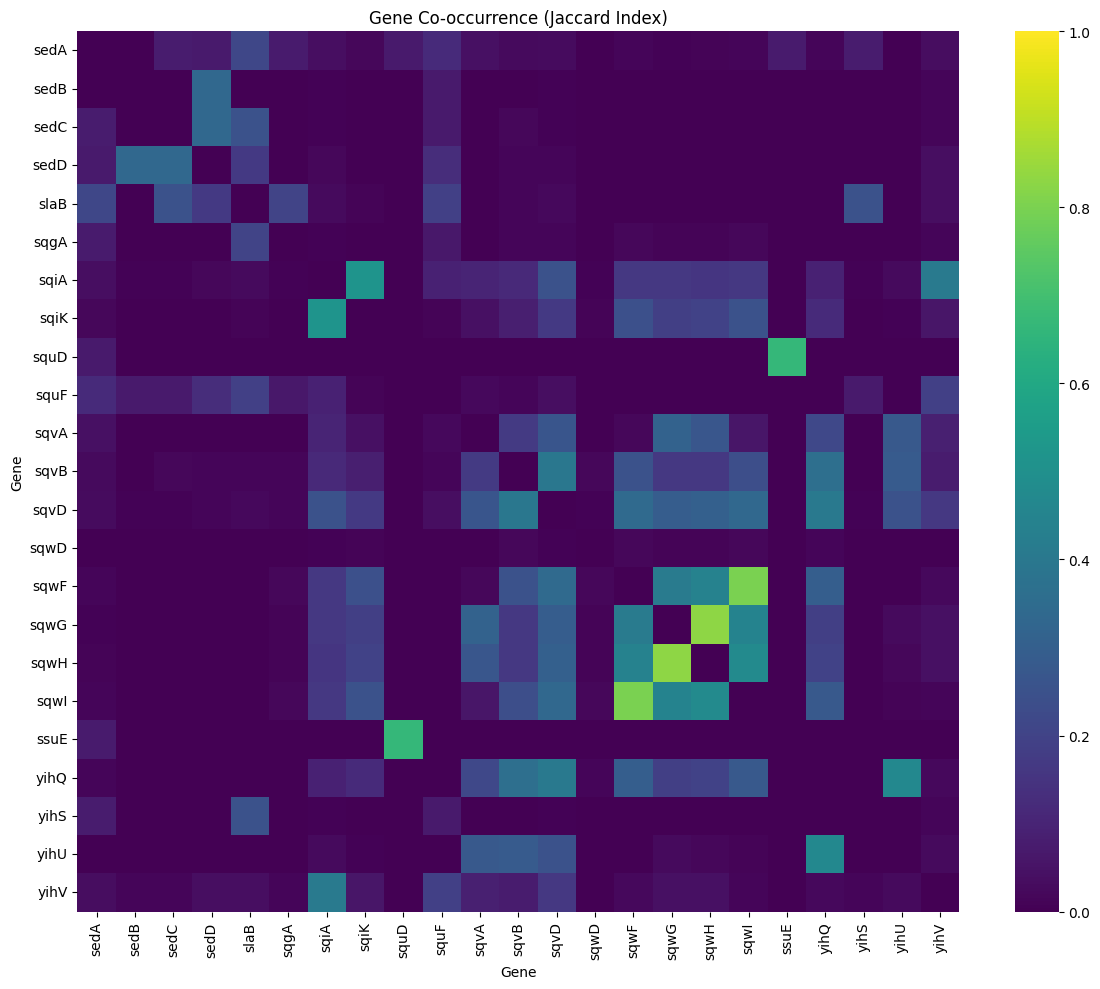

In [25]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    jaccard,
    cmap="viridis",
    vmin=0,
    vmax=1
)

plt.title("Gene Co-occurrence (Jaccard Index)")
plt.tight_layout()
plt.savefig("pictures/co-occurence/heatmap.png", dpi=300)
plt.show()

/tmp/ipykernel_21169/2860045195.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


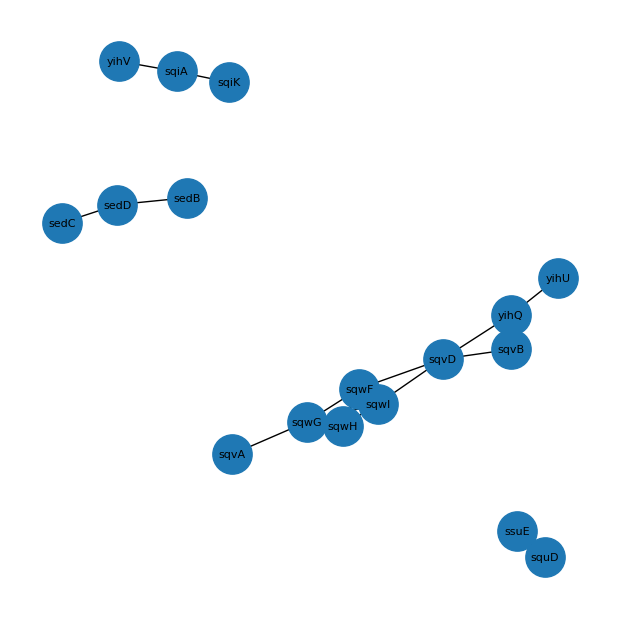

In [42]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.Graph()

threshold = 0.311

for i in jaccard.index:
    for j in jaccard.columns:
        if i != j and jaccard.loc[i, j] > threshold:
            G.add_edge(i, j, weight=jaccard.loc[i, j])

plt.figure(figsize=(6, 6))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=800,
    font_size=8
)

plt.tight_layout()
plt.savefig("pictures/co-occurence/gene_network.png", dpi=300)
plt.show()

In [27]:
presence_matrix = presence_matrix.merge(
    df[["MAG", "Phylum"]].drop_duplicates(),
    on="MAG",
    how="left"
)

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


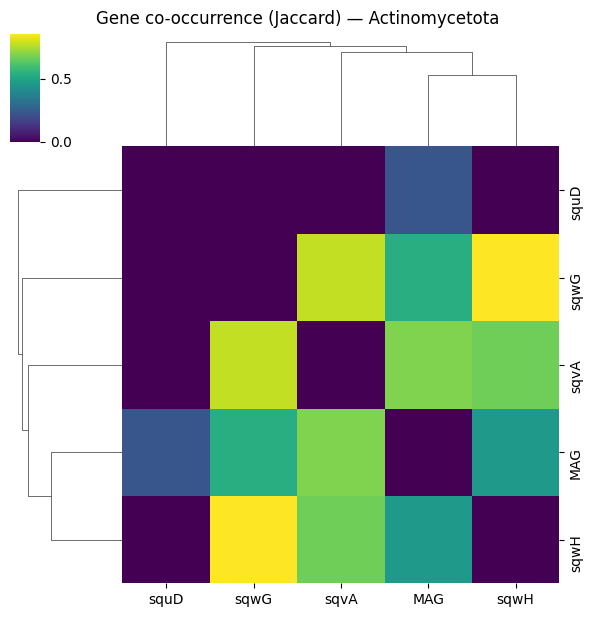

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


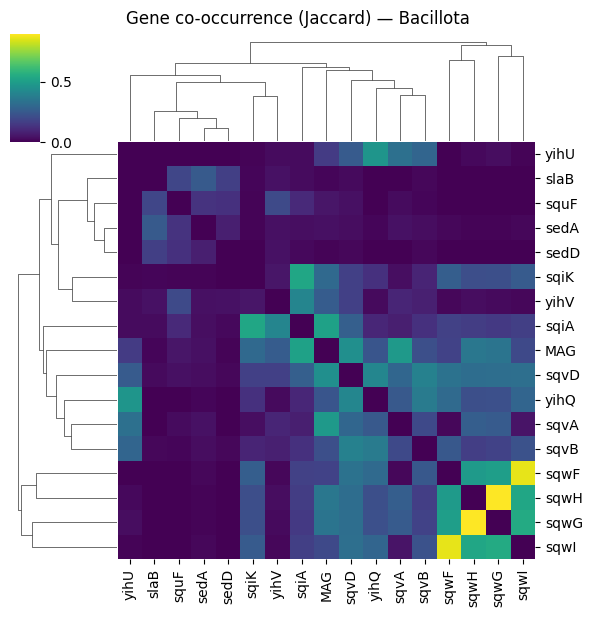

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


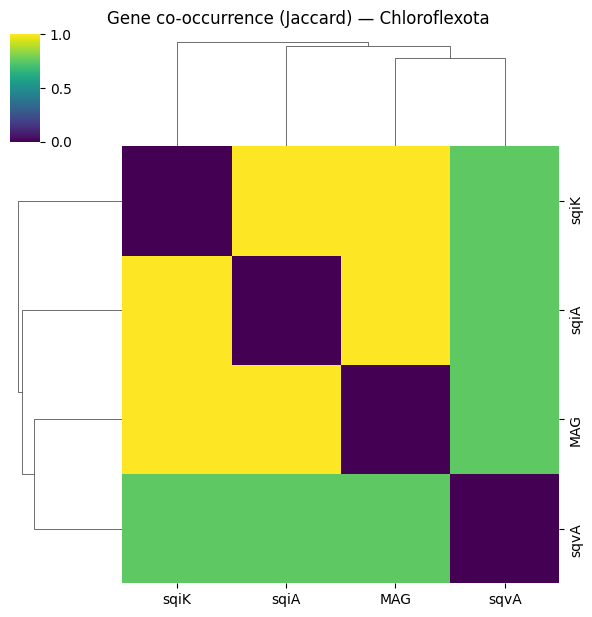

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


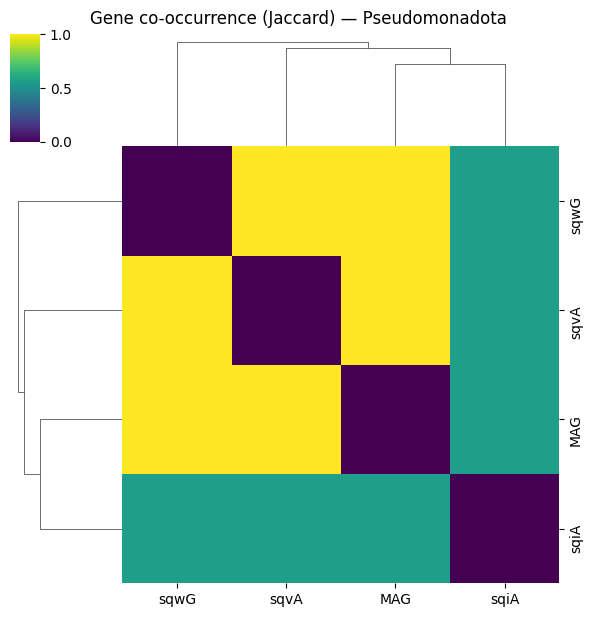

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


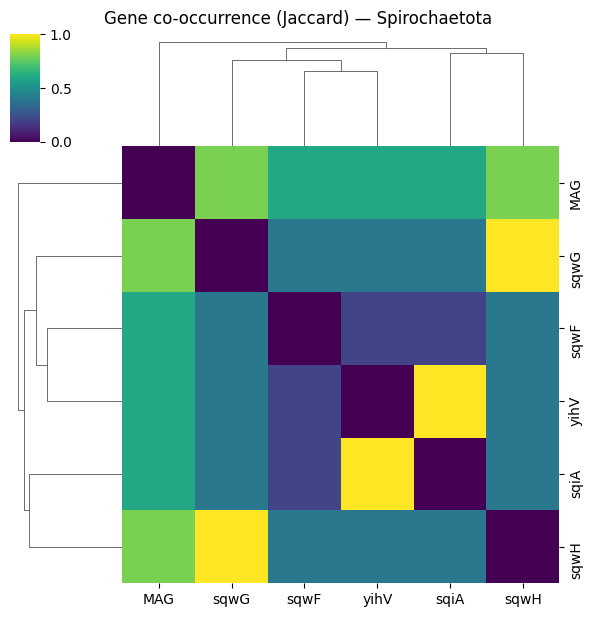

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


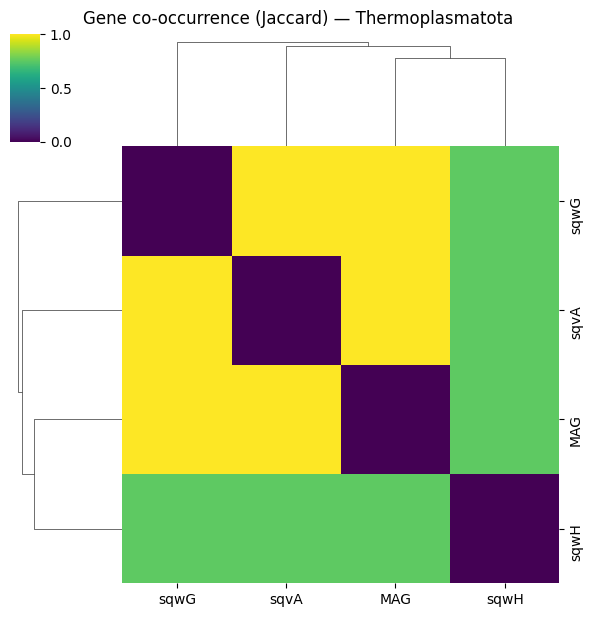

Skipping Verrucomicrobiota (too few MAGs)


In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

target_phyla = [
    "Actinomycetota",
    "Bacillota",
    "Chloroflexota",
    "Pseudomonadota",
    "Spirochaetota",
    "Thermoplasmatota",
    "Verrucomicrobiota"
]

filtered_matrix = presence_matrix[
    presence_matrix["Phylum"].isin(target_phyla)
]

tax_cols = ["Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

for phylum, group in filtered_matrix.groupby("Phylum"):

    # ----------------------------
    # только гены
    # ----------------------------
    mat = group.drop(columns=tax_cols, errors="ignore")

    if mat.shape[0] < 3:
        print(f"Skipping {phylum} (too few MAGs)")
        continue

    # ----------------------------
    # БИНАРИЗАЦИЯ (ВАЖНО!)
    # ----------------------------
    mat_bin = mat.astype(bool).astype(int)

    # ----------------------------
    # JACCARD
    # ----------------------------
    intersection = (mat_bin.T @ mat_bin).values
    counts = mat_bin.sum(axis=0).values

    union = np.add.outer(counts, counts) - intersection
    union = union.astype(float)
    union[union == 0] = np.nan

    jaccard_phylum = pd.DataFrame(
        intersection / union,
        index=mat.columns,
        columns=mat.columns
    ).fillna(0)

    np.fill_diagonal(jaccard_phylum.values, 0)

    # ----------------------------
    # ❗ ВАЖНО: фильтр редких генов (очень улучшает heatmap)
    # ----------------------------
    gene_freq = mat_bin.sum(axis=0)
    keep_genes = gene_freq[gene_freq >= 3].index

    jaccard_phylum = jaccard_phylum.loc[keep_genes, keep_genes]

    if jaccard_phylum.shape[0] < 3:
        print(f"Skipping {phylum} (too few genes after filtering)")
        continue

    # ----------------------------
    # CLUSTERMAP
    # ----------------------------
    g = sns.clustermap(
        jaccard_phylum,
        cmap="viridis",
        figsize=(6, 6),
        method="average",
        metric="euclidean",   # можно потом поменять
        xticklabels=1,
        yticklabels=1
    )

    g.fig.suptitle(f"Gene co-occurrence (Jaccard) — {phylum}", y=1.02)

    # ----------------------------
    # SAVE
    # ----------------------------
    filename = f"clustermap_{phylum.replace(' ', '_')}.png"
    g.savefig(f"pictures/co-occurence/{filename}", dpi=300, bbox_inches="tight")

    plt.show()